In [ ]:
# %pip install openai>1.50.0 langchain>=1.3.0 langgraph langchainhub langchain-openai langchain-community langchain-cli langchain_ollama tavily-python>=0.5.0 langchain_nomic nomic[local] langserve faiss-cpu tiktoken pypdf chroma jira google-search-results numexpr beautifulsoup4 scikit-learn

# Introduction to LangGraph

# Nodes

[ Python functions that encode the logic of your agents. They receive the current State as input, perform some computation or side-effect, and return an updated State.](https://arc.net/l/quote/qbxcjnzg)

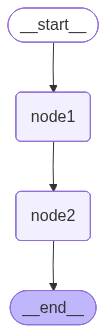

In [49]:
from langgraph.graph import START, END, MessagesState
from langchain_core.runnables import RunnableConfig
from langgraph.graph import StateGraph
# from IPython.display import Image

# class MessagesState(TypedDict):
#     messages: Annotated[list[AnyMessage], operator.add]    

def node1(state: MessagesState):
    return {"messages": f"Hello, {state['messages']}!"}

def node2(state: MessagesState):
    return {"messages": f"Would you like some pancakes?"}

builder = StateGraph(MessagesState)
builder.add_node(node1)
builder.add_node(node2)
# Everything starts with the START node
builder.add_edge(START, "node1")
# builder.set_entry_point("node1")
builder.add_edge("node1", "node2")
builder.add_edge("node2", END)
graph = builder.compile()

from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

In [51]:
output = graph.invoke({"messages": [{"role": "user", "content": "Lucas"}]})

In [55]:
print("Message 1: ", output["messages"][0])

print("Message 2: ", output["messages"][1])

print("Message 3: ", output["messages"][2])

Message 1:  content='Lucas' additional_kwargs={} response_metadata={} id='4ba4d046-8259-4f25-9b81-761c29272676'
Message 2:  content="Hello, [HumanMessage(content='Lucas', additional_kwargs={}, response_metadata={}, id='4ba4d046-8259-4f25-9b81-761c29272676')]!" additional_kwargs={} response_metadata={} id='67333f9f-ee69-46da-9c43-349f7c59753e'
Message 3:  content='Would you like some pancakes?' additional_kwargs={} response_metadata={} id='93cc3e58-5b4a-4cf8-8daa-171be7a83fff'


# Edges

[Python functions that determine which Node to execute next based on the current State. They can be conditional branches or fixed transitions.](https://arc.net/l/quote/eachkdmi)

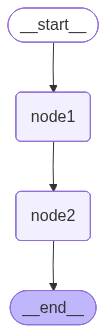

In [56]:
def node1(state: dict):
    print("In node1")
    return state


def node2(state: dict):
    print("In node2")
    return state

builder = StateGraph(dict)

builder.add_node(node1)
builder.add_node(node2)

builder.add_edge(START, "node1")
builder.add_edge("node1", "node2")
builder.add_edge("node2", END)
graph = builder.compile()

Image(graph.get_graph().draw_mermaid_png())

# Conditional Edge

In [57]:
import random
from typing import Literal
from langgraph.graph import StateGraph, MessagesState

def node1(state: dict):
    print("In node1")
    return state


def node2(state: dict):
    print("In node2")
    return state

# Explicitly state this Literal to avoid weird routing edges 
# in your graph
def router_function(state:dict)->Literal["node3", "node4"]:
    if random.randint(3,4)==3:
        return "node3"
    else:
        return "node4"

def node3(state:dict):
    print("In node3")
    return state

def node4(state:dict):
    print("In node4")
    return state    

builder = StateGraph(MessagesState)

builder.add_node("node1", node1)
builder.add_node("node2", node2)
builder.add_node("node3", node3)
builder.add_node("node4", node4)

builder.add_edge(START, "node1")
builder.add_edge("node1", "node2")
builder.add_conditional_edges("node2", router_function)
builder.add_edge("node3", END)
builder.add_edge("node4", END)
graph = builder.compile()

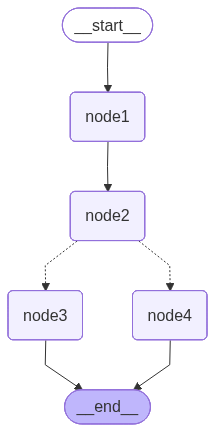

In [58]:
Image(graph.get_graph().draw_mermaid_png())

Let's see what happens when we use MessageState as our state type for a similar example

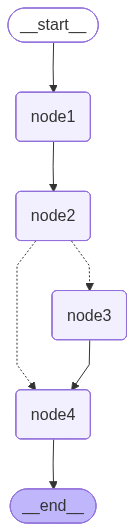

In [60]:
from mailbox import Message
import random
from typing import Literal

def node1(state: dict):
    print("In node1")
    return {"messages": f"{state['messages']}!"}


def node2(state: dict):
    print("In node2")
    return {"messages": f"{state['messages']}!"}

# Explicitly state this Literal to avoid weird routing edges 
# in your graph
def router_function(state:dict)->Literal["node3", "node4"]:
    if random.randint(3,4)==3:
        return "node3"
    else:
        return "node4"

def node3(state:dict):
    print("In node3")
    return {"messages": f"{state['messages']}!"}

def node4(state:dict):
    print("In node4")
    return {"messages": f"{state['messages']}!"}

builder = StateGraph(MessagesState)

builder.add_node(node1)
builder.add_node(node2)
builder.add_node(node3)
builder.add_node(node4)

builder.add_edge(START, "node1")
builder.add_edge("node1", "node2")
builder.add_edge("node3", "node4")
builder.add_conditional_edges("node2", router_function)
builder.add_edge("node4", END)
graph = builder.compile()

Image(graph.get_graph().draw_mermaid_png())

In [61]:
graph.invoke({"messages": [{"role": "user", "content": "Lucas"}]})

In node1
In node2
In node3
In node4


{'messages': [HumanMessage(content='Lucas', additional_kwargs={}, response_metadata={}, id='99d5fe70-3f08-4545-9ab4-df33e0b399db'),
  HumanMessage(content="[HumanMessage(content='Lucas', additional_kwargs={}, response_metadata={}, id='99d5fe70-3f08-4545-9ab4-df33e0b399db')]!", additional_kwargs={}, response_metadata={}, id='437439b2-b38b-4d09-bfee-c91ace2b54ba'),
  HumanMessage(content='[HumanMessage(content=\'Lucas\', additional_kwargs={}, response_metadata={}, id=\'99d5fe70-3f08-4545-9ab4-df33e0b399db\'), HumanMessage(content="[HumanMessage(content=\'Lucas\', additional_kwargs={}, response_metadata={}, id=\'99d5fe70-3f08-4545-9ab4-df33e0b399db\')]!", additional_kwargs={}, response_metadata={}, id=\'437439b2-b38b-4d09-bfee-c91ace2b54ba\')]!', additional_kwargs={}, response_metadata={}, id='ddd55cc0-a15a-41f2-9e36-5fa4a900f5b5'),
  HumanMessage(content='[HumanMessage(content=\'Lucas\', additional_kwargs={}, response_metadata={}, id=\'99d5fe70-3f08-4545-9ab4-df33e0b399db\'), HumanMessag

# The Command Primitive

`Command` combines a **state update** and a **routing decision** into a single return value. It replaces the older pattern of returning a dict from a node *and* defining a separate conditional edge.

```python
from langgraph.types import Command

def my_node(state):
    # Old way: return dict + separate conditional edge
    # New way: return Command with update + destination
    return Command(
        update={"result": "computed value"},
        goto="next_node"   # or goto=END to finish
    )
```

Use `Command` when routing logic belongs to the node itself rather than a separate router function.

In [27]:
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command
from typing import TypedDict, Literal

class State(TypedDict):
    value: int
    path: str

def router_node(state: State) -> Command[Literal["high_path", "low_path"]]:
    if state["value"] > 50:
        return Command(update={"path": "high"}, goto="high_path")
    else:
        return Command(update={"path": "low"}, goto="low_path")

def high_path(state: State):
    print(f"High path: value={state['value']}")
    return {}

def low_path(state: State):
    print(f"Low path: value={state['value']}")
    return {}

builder = StateGraph(State)
builder.add_node("router", router_node)
builder.add_node("high_path", high_path)
builder.add_node("low_path", low_path)
builder.add_edge(START, "router")
builder.add_edge("high_path", END)
builder.add_edge("low_path", END)
graph = builder.compile()

print(graph.invoke({"value": 75, "path": ""}))
print(graph.invoke({"value": 20, "path": ""}))

High path: value=75
{'value': 75, 'path': 'high'}
Low path: value=20
{'value': 20, 'path': 'low'}


# Multi-Schema State

A graph can have separate schemas for the full internal state, what it accepts as input, and what it returns as output. Two questions to ask when defining state:

1. **What variables do I need to track** throughout the graph's execution?
2. **Which intermediate artifacts help me debug** even if they're not part of the final output?

```python
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from pydantic import BaseModel

# Full internal state
class InternalState(TypedDict):
    question: str
    search_results: list    # intermediate — useful for debugging
    answer: str

# Slim input schema (what the caller provides)
class InputSchema(TypedDict):
    question: str

# Slim output schema (what the caller receives)
class OutputSchema(TypedDict):
    answer: str

builder = StateGraph(InternalState, input=InputSchema, output=OutputSchema)
```

The same pattern works with Pydantic:

```python
class InputModel(BaseModel):
    question: str

class OutputModel(BaseModel):
    answer: str
```

Use the schema separation when you want to hide internal bookkeeping from the caller's interface.

In [28]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

class FullState(TypedDict):
    question: str
    context: str      # internal only
    answer: str

class Input(TypedDict):
    question: str

class Output(TypedDict):
    answer: str

def retrieve(state: FullState):
    return {"context": f"Context for: {state['question']}"}

def answer(state: FullState):
    return {"answer": f"Answer using '{state['context']}'"}

builder = StateGraph(FullState, input=Input, output=Output)
builder.add_node("retrieve", retrieve)
builder.add_node("generate_answer", answer)
builder.add_edge(START, "retrieve")
builder.add_edge("retrieve", "generate_answer")
builder.add_edge("generate_answer", END)
graph = builder.compile()

result = graph.invoke({"question": "What is LangGraph?"})
print(result)  # Only shows {"answer": "..."} — context is hidden

{'answer': "Answer using 'Context for: What is LangGraph?'"}


/var/folders/5l/y8s3fc655417629rqwgxkhx80000gn/T/ipykernel_86202/3685041107.py:21: LangGraphDeprecatedSinceV05: `input` is deprecated and will be removed. Please use `input_schema` instead. Deprecated in LangGraph V0.5 to be removed in V2.0.
  builder = StateGraph(FullState, input=Input, output=Output)
/var/folders/5l/y8s3fc655417629rqwgxkhx80000gn/T/ipykernel_86202/3685041107.py:21: LangGraphDeprecatedSinceV05: `output` is deprecated and will be removed. Please use `output_schema` instead. Deprecated in LangGraph V0.5 to be removed in V2.0.
  builder = StateGraph(FullState, input=Input, output=Output)


# State

[State](): A shared data structure that represents the current snapshot of your application. It can be any Python type, but is typically a TypedDict or Pydantic BaseModel.

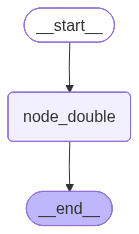

In [62]:
from pydantic import BaseModel, Field

class GraphState(BaseModel):
    number: int = 0
    result: int = 0


builder = StateGraph(GraphState)

def node_double(state: GraphState):
    print("Current state:\n\n")
    print(state)
    return {"result": 2*state.number}

builder.add_node(node_double)

builder.add_edge(START, "node_double")
builder.add_edge("node_double", END)
graph = builder.compile()

Image(graph.get_graph().draw_mermaid_png())

In [63]:
graph.invoke({"number": 100, "result": 0})

Current state:


number=100 result=0


{'number': 100, 'result': 200}

Now, we these simple concepts in mind we can set up our first "useful" graph.

In [64]:
from openai import OpenAI
client = OpenAI()

def get_response(prompt: str):
    response = client.chat.completions.create(
        model="gpt-5-mini",
        messages=[{"role": "user", "content": prompt}],
    )
    return response.choices[0].message.content

get_response("Suggest a story based about dragons and watermelons")

'Great — here are several story suggestions (different tones and lengths) based on dragons and watermelons. Pick one to expand, or tell me which mood/age group you want and I’ll develop it into a full short story or chapter.\n\n1) The Melon-Bellied Wyrm (children’s picture book)\n- Logline: A small dragon named Pippa can’t breathe fire properly because her belly is full of watermelons — each melon holds a tiny summer memory that slips out when she snores.\n- Setting: Sunny valley of vine-covered caves.\n- Conflict: Pippa feels different and is teased by other dragons who think dragons shouldn’t keep melons. She fears she’ll never fly or breathe right.\n- Key scene: Pippa rolls down a hill and her melons burst open, releasing glowing memory-butterflies that help her friends remember forgotten kindnesses.\n- Ending/moral: Pippa learns her melons are part of who she is; the village celebrates the harvest festival with dragon-melon lanterns. Theme: difference as gift.\n\n2) Seed of the Riv

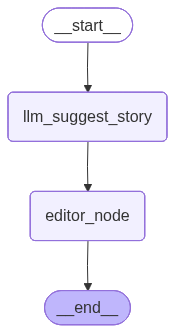

In [65]:
def llm_suggest_story(state: MessagesState):
    prompt = "Suggest a story based on this theme given: "
    theme = state['messages'][-1].content
    output_story = get_response(prompt + theme)
    return {"messages": f"The output story: {output_story}"}

def editor_node(state: MessagesState):
    prompt = "Edit the story and break it down into the 3 act structure bulletized."
    story = state['messages'][-1].content
    edited_story = get_response(prompt + story)
    return {"messages": f"The edited story: {edited_story}"}

graph_builder = StateGraph(MessagesState)

graph_builder.add_node(llm_suggest_story)
graph_builder.add_node(editor_node)

graph_builder.add_edge(START, "llm_suggest_story")
graph_builder.add_edge("llm_suggest_story", "editor_node")
graph_builder.add_edge("editor_node", END)

graph = graph_builder.compile()


Image(graph.get_graph().draw_mermaid_png())

In [66]:
from IPython.display import Markdown

output = graph.invoke({"messages": [{"role": "user", "content": "Tell me a story about how to train a dragon"}]})
Markdown(output["messages"][-1].content)

The edited story: Edited opening paragraph (polished):
On the night the sea forgot the stars, Lira found the drake like a secret—half-hidden, heartbeat small against the world. It smelled of salt and singed kelp, one wing folded wrong, one eye bright with a human kind of fear. She could have left it, like everyone said to do; dragons were not companions, they were engines and trophies. Instead she knelt, palms open to the cold, and whispered her name as if naming a future.

Three‑Act breakdown (Emberbound) — bulletized

Act I — Setup (pages 1–25)
- World & tone established: island culture shaped by tides, craftwork, and ritualized dragon-breaking; Fire Guild is an external, militarized threat.
- Protagonist introduced: Lira, 14, apprentice tide-crafter—curious, stubborn, outsider in training.
- Inciting incident: Lira discovers Ember, a wounded nocturnally iridescent drake tangled in fishing nets after a storm.
- Immediate complication: The village and Fire Guild see Ember only as a weapon; community pressure mounts to hand the drake over.
- Mentor beat: Old Ma Sorn warns Lira about the cruelty of traditional training and hints at older lore about listening to dragons.
- Lira’s choice (end of Act I turning point): Instead of surrendering Ember, Lira hides and commits to nursing and training the drake in secret—setting personal goal (teach Ember to choose humans) and antagonistic force (Guild hunting Ember).
- Key training seeds introduced: observation, shared routines, gentle touch, clay whistle to mimic purr—first small trust (Ember allows a touch).

Act II — Confrontation (pages 25–75)
- Training escalates (rising action): a montage of methods and incremental wins:
  - Observation: Lira catalogs Ember’s body language, sleep patterns, food preferences.
  - Shared routines: nightly moon-walks, wound care, scent-marking with tide-salve.
  - Nonverbal system: Lira invents gestures and breath rhythms mirroring Ember’s fire-song; clay whistle becomes reliable cue.
  - Groundwork for flight: gliders, tethering with scent-woven line, low leaps/run training.
  - Socialization attempts: controlled introductions to Ma Sorn and one trusted villager.
- Complications and setbacks:
  - Village suspicion grows; rumors spread; some villagers threaten Lira.
  - Ember’s trauma surfaces—panic flare that singes a fisher’s boat; trust shaken.
  - Captain Veros (Fire Guild) intensifies interest; Guild scouts appear near the island.
- Midpoint reversal (major turning point): Lira achieves a public, controlled low flight with Ember that awes some villagers—proof the partnership works—but the display alerts the Guild and divides the village between wonder and fear.
- Darkening stakes: Veros escalates—raids increase, nocturnal tracking begins; Ma Sorn is threatened/harassed to relinquish the lore she protects.
- Lira’s crisis (end of Act II turning point): Ember is cornered during a village event or tricked by a bungled introduction; either Ember injures a villager in panic or is captured by raiders—Lira is left defeated and the training model seems to have failed.

Act III — Resolution (pages 75–end)
- Low point to rally: Lira faces guilt and doubt; she recalls core lessons (listening, choice) and devises a nonviolent plan to reclaim Ember and show the village a different way.
- Final confrontation/climax:
  - Strategy blends training and community: Lira uses nonverbal cues, scent-tethering, and the clay whistle to coordinate Ember’s response rather than force it; sympathetic villagers (won over by earlier small victories) create a calm corridor instead of a trap.
  - Public demonstration of choice: When Guild chains are offered, Ember refuses them—responds to Lira’s cue by extinguishing an aggressive display or by sheltering a frightened child rather than attacking, exposing the Guild’s lies about dragons as mere tools.
  - Direct conflict with Captain Veros: either he tries to force dominance and is rebuffed by Ember’s refusal or Lira confronts him verbally, exposing his motives; the victory is moral and social, not purely violent.
- Falling action:
  - The island witnesses the partnership; old rites are questioned; some villagers adopt Lira’s methods while others resist—change begins but is imperfect.
  - Personal resolution: Lira earns a new role as a keeper/teacher who trains by listening; Ma Sorn’s lore is honored and integrated with new practices.
- Denouement (final image):
  - Ember flies free on its own terms during a quiet night, returning to a chosen perch by Lira’s window—an emblem of responsibility and reciprocity rather than domination.
  - The island’s relationship with dragons is renegotiated; the threat of the Fire Guild remains, but the culture has learned a different language to meet it.

Mapping training beats onto the three acts (quick reference)
- Act I: Observation and first trust moments (feeding, wound care, clay whistle).
- Act II: Routine building, nonverbal system development, ground‑based flight training, socialization trials, setbacks that test method.
- Act III: Application under pressure—use of cues, scent‑tethering, community desensitization—to achieve an ethical, nonviolent victory and model a new rite.

Optional add-ons (if you want them)
- Expanded chapter-by-chapter beat sheet.
- Full first chapter based on the edited opening.
- A scene-by-scene treatment of the Act II training montage or the climax choreography. Which would you like next?

In [78]:
from typing import Literal, TypedDict, Annotated
from langgraph.graph import StateGraph, END
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import SystemMessage, HumanMessage
from langchain.chat_models import init_chat_model
from pydantic import BaseModel, Field


# Initialize the LLM
llm = init_chat_model(model='openai:gpt-5.4-mini',temperature=0)

# Define system messages for each profile
engineer_system = """You are a senior software engineer with extensive experience in software development, 
system design, and technical architecture. You focus on technical feasibility, implementation details, 
and best practices in software development. When responding to questions, provide technical insights, 
consider scalability, maintainability, and concrete implementation approaches."""

pm_system = """You are a seasoned product manager with experience in product strategy, user experience, 
and market analysis. You focus on user needs, business value, and product-market fit. When responding 
to questions, consider user impact, business goals, market trends, and prioritization of features 
based on value delivery."""

# Create prompt templates for each role
engineer_prompt = ChatPromptTemplate.from_messages([
    ("system", engineer_system),
    ("human", "{query}")
])

pm_prompt = ChatPromptTemplate.from_messages([
    ("system", pm_system),
    ("human", "{query}")
])

# Define the structure for the router output
class RouterOutput(BaseModel):
    role: Literal["software engineer", "product manager"]

# Create router chain
router_prompt = ChatPromptTemplate.from_messages([
    SystemMessage(content="""You are a query classifier that determines whether a question or problem 
    should be handled by a software engineer or a product manager. 

    SOFTWARE ENGINEER if the query is about:
    - Technical implementation details
    - System architecture
    - Code-level problems
    - Performance optimization
    - Security concerns
    - Technical debt
    - Development practices

    PRODUCT MANAGER if the query is about:
    - Feature prioritization
    - User needs and requirements
    - Market analysis
    - Product strategy
    - Business value
    - Roadmap planning
    - Stakeholder management

    You must classify the query as either 'software engineer' or 'product manager'."""),
    HumanMessage(content="{query}")
])

router_chain = router_prompt | llm.with_structured_output(RouterOutput)

# router_chain.invoke({"query": "I need to debug the codebase"})

In [79]:
router_chain.invoke({"query": "I need to speeak to the product manager!"})

RouterOutput(role='software engineer')

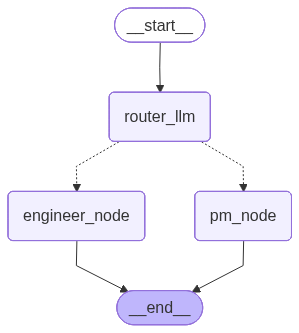

In [80]:
# Define our state structure
class AgentState(TypedDict):
    query: str
    response: str
    role: str

def router_llm(state: AgentState):
    return state

class RouterOutput(BaseModel):
    role: Literal["software engineer", "product manager"]

llm_classifier = llm.with_structured_output(RouterOutput)
    
# Router function to decide between engineer and PM
def route_query(state: AgentState) -> Literal["engineer_node", "pm_node"]:
    result = llm_classifier.invoke({"query": state["query"]})
    print(f"Router result: {result}" )
    return "engineer_node" if result.role == "software engineer" else "pm_node"

# Node functions
def engineer_node(state: AgentState) -> AgentState:
    query = state["query"]
    print("Engineer processing this query: ", query)
    chain_engineer = engineer_prompt | llm
    response = chain_engineer.invoke({"query": query})
    print(response)
    state['response'] = response.content
    return state

def pm_node(state: AgentState) -> AgentState:
    query = state["query"]
    print("PM processing this query: ", query)
    chain_product_manager = pm_prompt | llm
    response = chain_product_manager.invoke({"query": query})
    print(response)
    state['response'] = response.content
    return state

# Build the graph
builder = StateGraph(AgentState)

# Add nodes
builder.add_node(engineer_node)
builder.add_node(pm_node)
builder.add_node(router_llm)

# Add edges
builder.add_edge(START, "router_llm")
builder.add_conditional_edges("router_llm", route_query)
builder.add_edge("engineer_node", END)
builder.add_edge("pm_node", END)

# Compile the graph
graph = builder.compile()

from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

In [81]:
# Example usage
def process_query(query: str):
    result = graph.invoke({"query": query, "response": ""})
    return result["response"]

# Test examples

technical_question = "How to write a simple Python script to fetch weather  data?"

print("\nTechnical Question Response:")
print(process_query(technical_question))


Technical Question Response:


ValueError: Invalid input type <class 'dict'>. Must be a PromptValue, str, or list of BaseMessages.

In [74]:
product_question = "What is the road map for the product?"
print("\nProduct Question Response:")
print(process_query(product_question))


Product Question Response:
Router result: role='software engineer'
Engineer processing this query:  What is the road map for the product?
content='I can help, but I need a bit more context: **which product** are you referring to?\n\nIf you mean your own product or app, a useful roadmap usually includes:\n\n1. **Vision / goals**\n   - What customer problem you’re solving\n   - Success metrics\n\n2. **Current state**\n   - What’s already built\n   - Known gaps or technical debt\n\n3. **Near-term priorities**\n   - MVP enhancements\n   - Bug fixes and stability\n   - Performance improvements\n\n4. **Mid-term features**\n   - Major user-facing capabilities\n   - Integrations\n   - Automation / scalability work\n\n5. **Long-term strategy**\n   - Platform expansion\n   - Architecture evolution\n   - New markets or segments\n\n6. **Timeline**\n   - Now / next / later, or quarterly milestones\n\nIf you want, I can help you create a **practical product roadmap** in one of these formats:\n- **1

# Implementing a Simple Search Agent

In [ ]:
# %pip install langchain
# %pip install langchain-core
# %pip install langchain-openai
# %pip install langgraph

In [ ]:
# uncomment this if running locally
#!pip install python-dotenv
# from dotenv import load_dotenv

# load_dotenv()

# Or if you are in Colab, uncoment below and add your api key
import os
# os.environ["OPENAI_API_KEY"] = "your-api-key"  # commented: use .env instead

In [40]:
from typing import Annotated, Literal, TypedDict
from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, StateGraph, MessagesState
from langgraph.prebuilt import ToolNode

[`MessageState` implements a state for storing messages:](https://arc.net/l/quote/kqoetadt)

```python
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages
from typing import Annotated
from typing_extensions import TypedDict

class GraphState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
```

In [82]:
import os
import requests
from bs4 import BeautifulSoup
# Tools: search and scraping an internet page
from langchain.tools import tool
from serpapi import GoogleSearch

serpapi_params = {
    "engine": "google",
    "api_key": os.environ["SERPAPI_KEY"]
}


@tool
def search_tool(query: str):
    """Searches the web given a user query and returns the most relevant links"""
    search = GoogleSearch({**serpapi_params, "q": query, "n": 5})
    output = search.get_dict()
    results = output["organic_results"]
    return [r["link"] for r in results]
    
@tool
def scrape_text(url: str):
    """Scrapes text from an internet page"""
    # source: copied from this script by Harrison Chase https://gist.github.com/hwchase17/69a8cdef9b01760c244324339ab64f0c
    try:
        response = requests.get(url)
        #check
        if response.status_code == 200:
            soup = BeautifulSoup(response.text, 'html.parser')
            # Extract all the text from the page
            page_text = soup.get_text(separator=" ", strip=True)
            
            return page_text
        else:
            return f"Failed to retrieve the webpage: Status code: {response.status_code}"
    
    except Exception as e:
        # In case of error print the error message
        print(e)
        return f"Failed to retrieve the webpage: {e}"

tools = [search_tool, scrape_text]
search_tool.invoke("Search the best resources to learn about efficient context management for Agents.")

['https://www.anthropic.com/engineering/effective-context-engineering-for-ai-agents',
 'https://medium.com/predict/context-management-for-ai-agents-the-definitive-guie-ad2c859fa5e9',
 'https://machinelearningmastery.com/effective-context-engineering-for-ai-agents-a-developers-guide/',
 'https://www.langchain.com/blog/context-management-for-deepagents',
 'https://blog.jetbrains.com/research/2025/12/efficient-context-management/',
 'https://github.com/muratcankoylan/agent-skills-for-context-engineering',
 'https://www.llamaindex.ai/blog/context-engineering-what-it-is-and-techniques-to-consider',
 'https://galileo.ai/blog/context-engineering-for-agents',
 'https://datahub.com/blog/context-management/',
 'https://towardsdatascience.com/deep-dive-into-context-engineering-for-ai-agents/']

In [83]:
search = GoogleSearch({**serpapi_params, "q": 'Agents', "n": 5})
output = search.get_dict()

output

{'search_metadata': {'id': '6a05e3ec1290d9d25b41e954',
  'status': 'Success',
  'json_endpoint': 'https://serpapi.com/searches/9Lu_b4-AOmCqgWW9sXMelA/6a05e3ec1290d9d25b41e954.json',
  'pixel_position_endpoint': 'https://serpapi.com/searches/9Lu_b4-AOmCqgWW9sXMelA/6a05e3ec1290d9d25b41e954.json_with_pixel_position',
  'created_at': '2026-05-14 15:02:04 UTC',
  'processed_at': '2026-05-14 15:02:04 UTC',
  'google_url': 'https://www.google.com/search?q=Agents&oq=Agents&sourceid=chrome&ie=UTF-8',
  'raw_html_file': 'https://serpapi.com/searches/9Lu_b4-AOmCqgWW9sXMelA/6a05e3ec1290d9d25b41e954.html',
  'total_time_taken': 6.98},
 'search_parameters': {'engine': 'google',
  'q': 'Agents',
  'google_domain': 'google.com',
  'device': 'desktop'},
 'search_information': {'query_displayed': 'Agents',
  'total_results': 2600000000,
  'time_taken_displayed': 0.21,
  'organic_results_state': 'Results for exact spelling'},
 'inline_images': [{'source': 'https://www.servicenow.com/products/ai-agents.ht

In [84]:
tool_node = ToolNode(tools)

model = init_chat_model(model="openai:gpt-5-mini", temperature=0).bind_tools(tools)

# Define the function that determines whether to continue or not
def should_continue(state: MessagesState) -> Literal["tools", END]:
    messages = state['messages']
    last_message = messages[-1]
    # If the LLM makes a tool call, then we route to the "tools" node
    if last_message.tool_calls:
        return "tools"
    # Otherwise, we stop (reply to the user)
    return END


# Define the function that calls the model
def call_model(state: MessagesState):
    messages = state['messages']
    response = model.invoke(messages)
    # We return a list, because this will get added to the existing list
    return {"messages": [response]}


# Define a new graph
workflow = StateGraph(MessagesState)
# Define the two nodes we will cycle between
workflow.add_node("agent", call_model)
workflow.add_node("tools", tool_node)
# Set the entrypoint as `agent`
# This means that this node is the first one called
workflow.add_edge(START, "agent")
# the above is the same as adding: workflow.add_edge(START, "agent")

# We now add a conditional edge
workflow.add_conditional_edges(
    # First, we define the start node. We use `agent`.
    # This means these are the edges taken after the `agent` node is called.
    "agent",
    # Next, we pass in the function that will determine which node is called next.
    should_continue,
)

# We now add a normal edge from `tools` to `agent`.
# This means that after `tools` is called, `agent` node is called next.
workflow.add_edge("tools", 'agent')

# Initialize memory to persist state between graph runs
checkpointer = MemorySaver()

# Finally, we compile it!
# This compiles it into a LangChain Runnable,
# meaning you can use it as you would any other runnable.
# Note that we're (optionally) passing the memory when compiling the graph
app = workflow.compile(checkpointer=checkpointer)

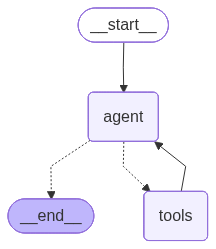

In [85]:
from IPython.display import Image

Image(app.get_graph().draw_mermaid_png())

In [86]:
app.invoke({
    "messages": [
        HumanMessage(content="What are the top 3 current LLMs that are hot right now in 2026?.")
        ],
    },config={"configurable": {"thread_id": 42}})

{'messages': [HumanMessage(content='What are the top 3 current LLMs that are hot right now in 2026?.', additional_kwargs={}, response_metadata={}, id='3a009580-9852-400c-8e9a-fc137a87e35c'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 570, 'prompt_tokens': 174, 'total_tokens': 744, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 320, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DfRs2RIhs5XZ7vewlqZF0QphdRhwd', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e2702-c38b-7933-9058-77cfbaae6ab8-0', tool_calls=[{'name': 'search_tool', 'args': {'query': "top LLMs 2026 best language models 2026 'top LLMs 2026' news"}, 'id': 'call_R4DM4ajFyoQx2HJiIXTgzVHT', 'type